In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from pymargins import Margins

rng = np.random.default_rng(42)
n = 400
df = pd.DataFrame(
    {
        "age": rng.integers(20, 75, n),
        "female": rng.binomial(1, 0.52, n),
        "treated": rng.binomial(1, 0.40, n),
        "school": rng.choice(["A", "B", "C", "D"], n),
        "student": np.repeat(np.arange(40), 10),
    }
)
# Random intercept per student
student_effect = rng.standard_normal(40)[df["student"].values]
df["score"] = (
    50
    + 0.3 * df["age"]
    - 2.0 * df["female"]
    + 3.0 * df["treated"]
    + student_effect
    + rng.normal(0, 5, n)
)

fit = smf.mixedlm(
    "score ~ age + female + treated + C(school)",
    groups="student",
    data=df,
).fit()

In [2]:
m = Margins.linear_scale(fit, at="overall")
print(m.dydx("age").summary())

            Margins Result (delta, level=0.95)           
     estimate  std err         z  P>|z|  [95% Conf. Int.]
---------------------------------------------------------
age    0.2940   0.0022  136.2542  0.000    0.2898, 0.2982

n = 400
κ: 0.000
Delta-vs-sim disagreement: 11.904%


In [3]:
print(m.predict(atexog={"treated": [0, 1]}).summary())

               Margins Result (delta, level=0.95)              
           estimate  std err         z  P>|z|  [95% Conf. Int.]
---------------------------------------------------------------
treated=0   62.3866   0.3799  164.2354  0.000  61.6421, 63.1311
treated=1   66.0406   0.4560  144.8329  0.000  65.1469, 66.9343

n = 400
κ: max=0.000
Delta-vs-sim disagreement: 0.103%


In [4]:
from pymargins import pairwise

scen, w = pairwise("treated", [1, 0])
print(m.contrasts(scenarios=scen, contrasts=w).summary())

              Margins Result (delta, level=0.95)             
           estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------
treated=1    3.6540   0.5504  6.6385  0.000    2.5752, 4.7328

n = 400
κ: 0.000
Delta-vs-sim disagreement: 2.344%


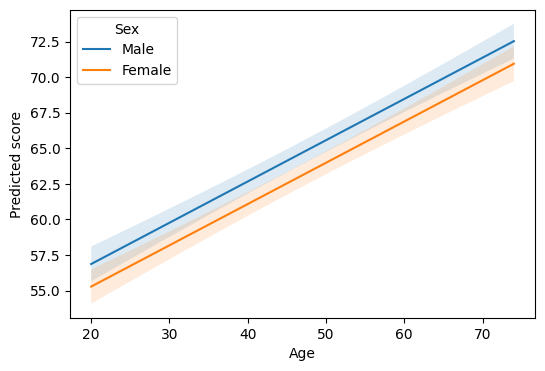

In [5]:
import matplotlib.pyplot as plt

ages = list(range(20, 76, 2))
res = m.predict(atexog={"age": ages, "female": [0, 1]})
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
for level, sub in df_plot.groupby("female"):
    label = "Female" if level == 1 else "Male"
    ax.plot(sub["age"], sub["estimate"], label=label)
    ax.fill_between(sub["age"], sub["ci_lower"], sub["ci_upper"], alpha=0.15)
ax.set(xlabel="Age", ylabel="Predicted score")
ax.legend(title="Sex")

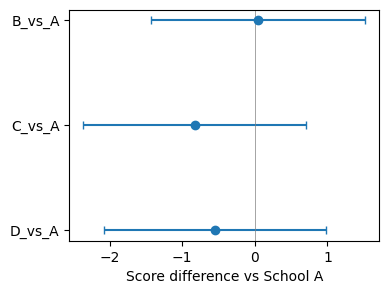

In [6]:
from pymargins import reference

scen, W = reference("school", ["A", "B", "C", "D"], ref_level="A")
res = m.contrasts(scenarios=scen, contrasts=W)
df_forest = res.to_frame()

fig, ax = plt.subplots(figsize=(4, 3))
y = range(len(df_forest))
ax.errorbar(
    df_forest["estimate"],
    y,
    xerr=[
        df_forest["estimate"] - df_forest["ci_lower"],
        df_forest["ci_upper"] - df_forest["estimate"],
    ],
    fmt="o",
    capsize=3,
)
ax.axvline(0, color="grey", lw=0.5)
ax.set_yticks(list(y))
ax.set_yticklabels(df_forest["label"])
ax.set_xlabel("Score difference vs School A")
ax.invert_yaxis()